In [11]:
import warnings

warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Library to split data
from sklearn.model_selection import train_test_split


# To build linear model for statistical analysis and prediction
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant

# To get diferent metric scores
from sklearn import metrics
from sklearn.metrics import accuracy_score, roc_curve, confusion_matrix, roc_auc_score

In [12]:
data = pd.read_csv('pima-indians-diabetes.csv')

In [13]:
data.head()

,Preg,Plas,Pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [14]:
data.isna().sum()

Preg     0
Plas     0
Pres     0
skin     0
test     0
mass     0
pedi     0
age      0
class    0
dtype: int64

In [15]:
data.isnull().sum()

Preg     0
Plas     0
Pres     0
skin     0
test     0
mass     0
pedi     0
age      0
class    0
dtype: int64

In [16]:
data.isin([0]).sum()

Preg     111
Plas       5
Pres      35
skin     227
test     374
mass      11
pedi       0
age        0
class    500
dtype: int64

In [22]:
data.rename(columns={'Plas':'Glucose',
                     'Pres':'BloodPressure',
                     'skin':'SkinThickness',
                     'test':'Insulin',
                     'mass':'BMI',
                     'pedi':'Pedigree',
                     'age':'Age',
                     'class':'Class'},inplace=True)

In [23]:
data.head()

,Preg,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Class
0,6,148.0,72.0,35.00000,155.548223,33.6,0.627,50,1
1,1,85.0,66.0,29.00000,155.548223,26.6,0.351,31,0
2,8,183.0,64.0,29.15342,155.548223,23.3,0.672,32,1
3,1,89.0,66.0,23.00000,94.000000,28.1,0.167,21,0
4,0,137.0,40.0,35.00000,168.000000,43.1,2.288,33,1


In [24]:
data.shape

(768, 9)

In [25]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
data[cols] = data[cols].replace(0, np.nan)
data[cols] = data[cols].fillna(data[cols].mean())
data.isna().sum()

Preg             0
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
Pedigree         0
Age              0
Class            0
dtype: int64

### Bivariate analysis

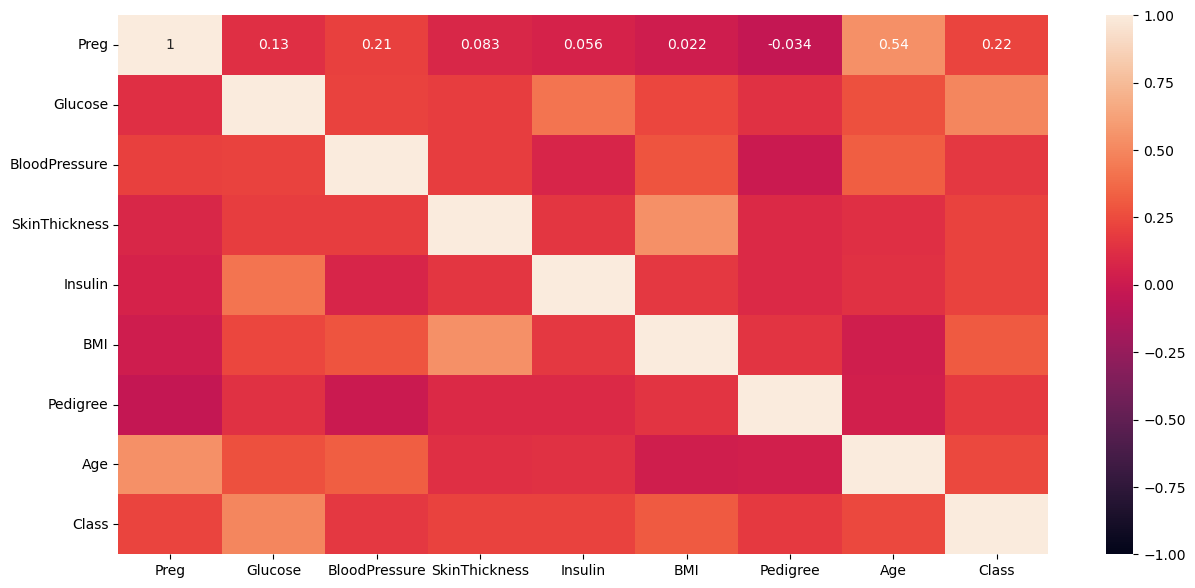

In [28]:
plt.figure(figsize=(15,7))
sns.heatmap(data.corr(), annot=True, vmin=-1, vmax=1)
plt.show();

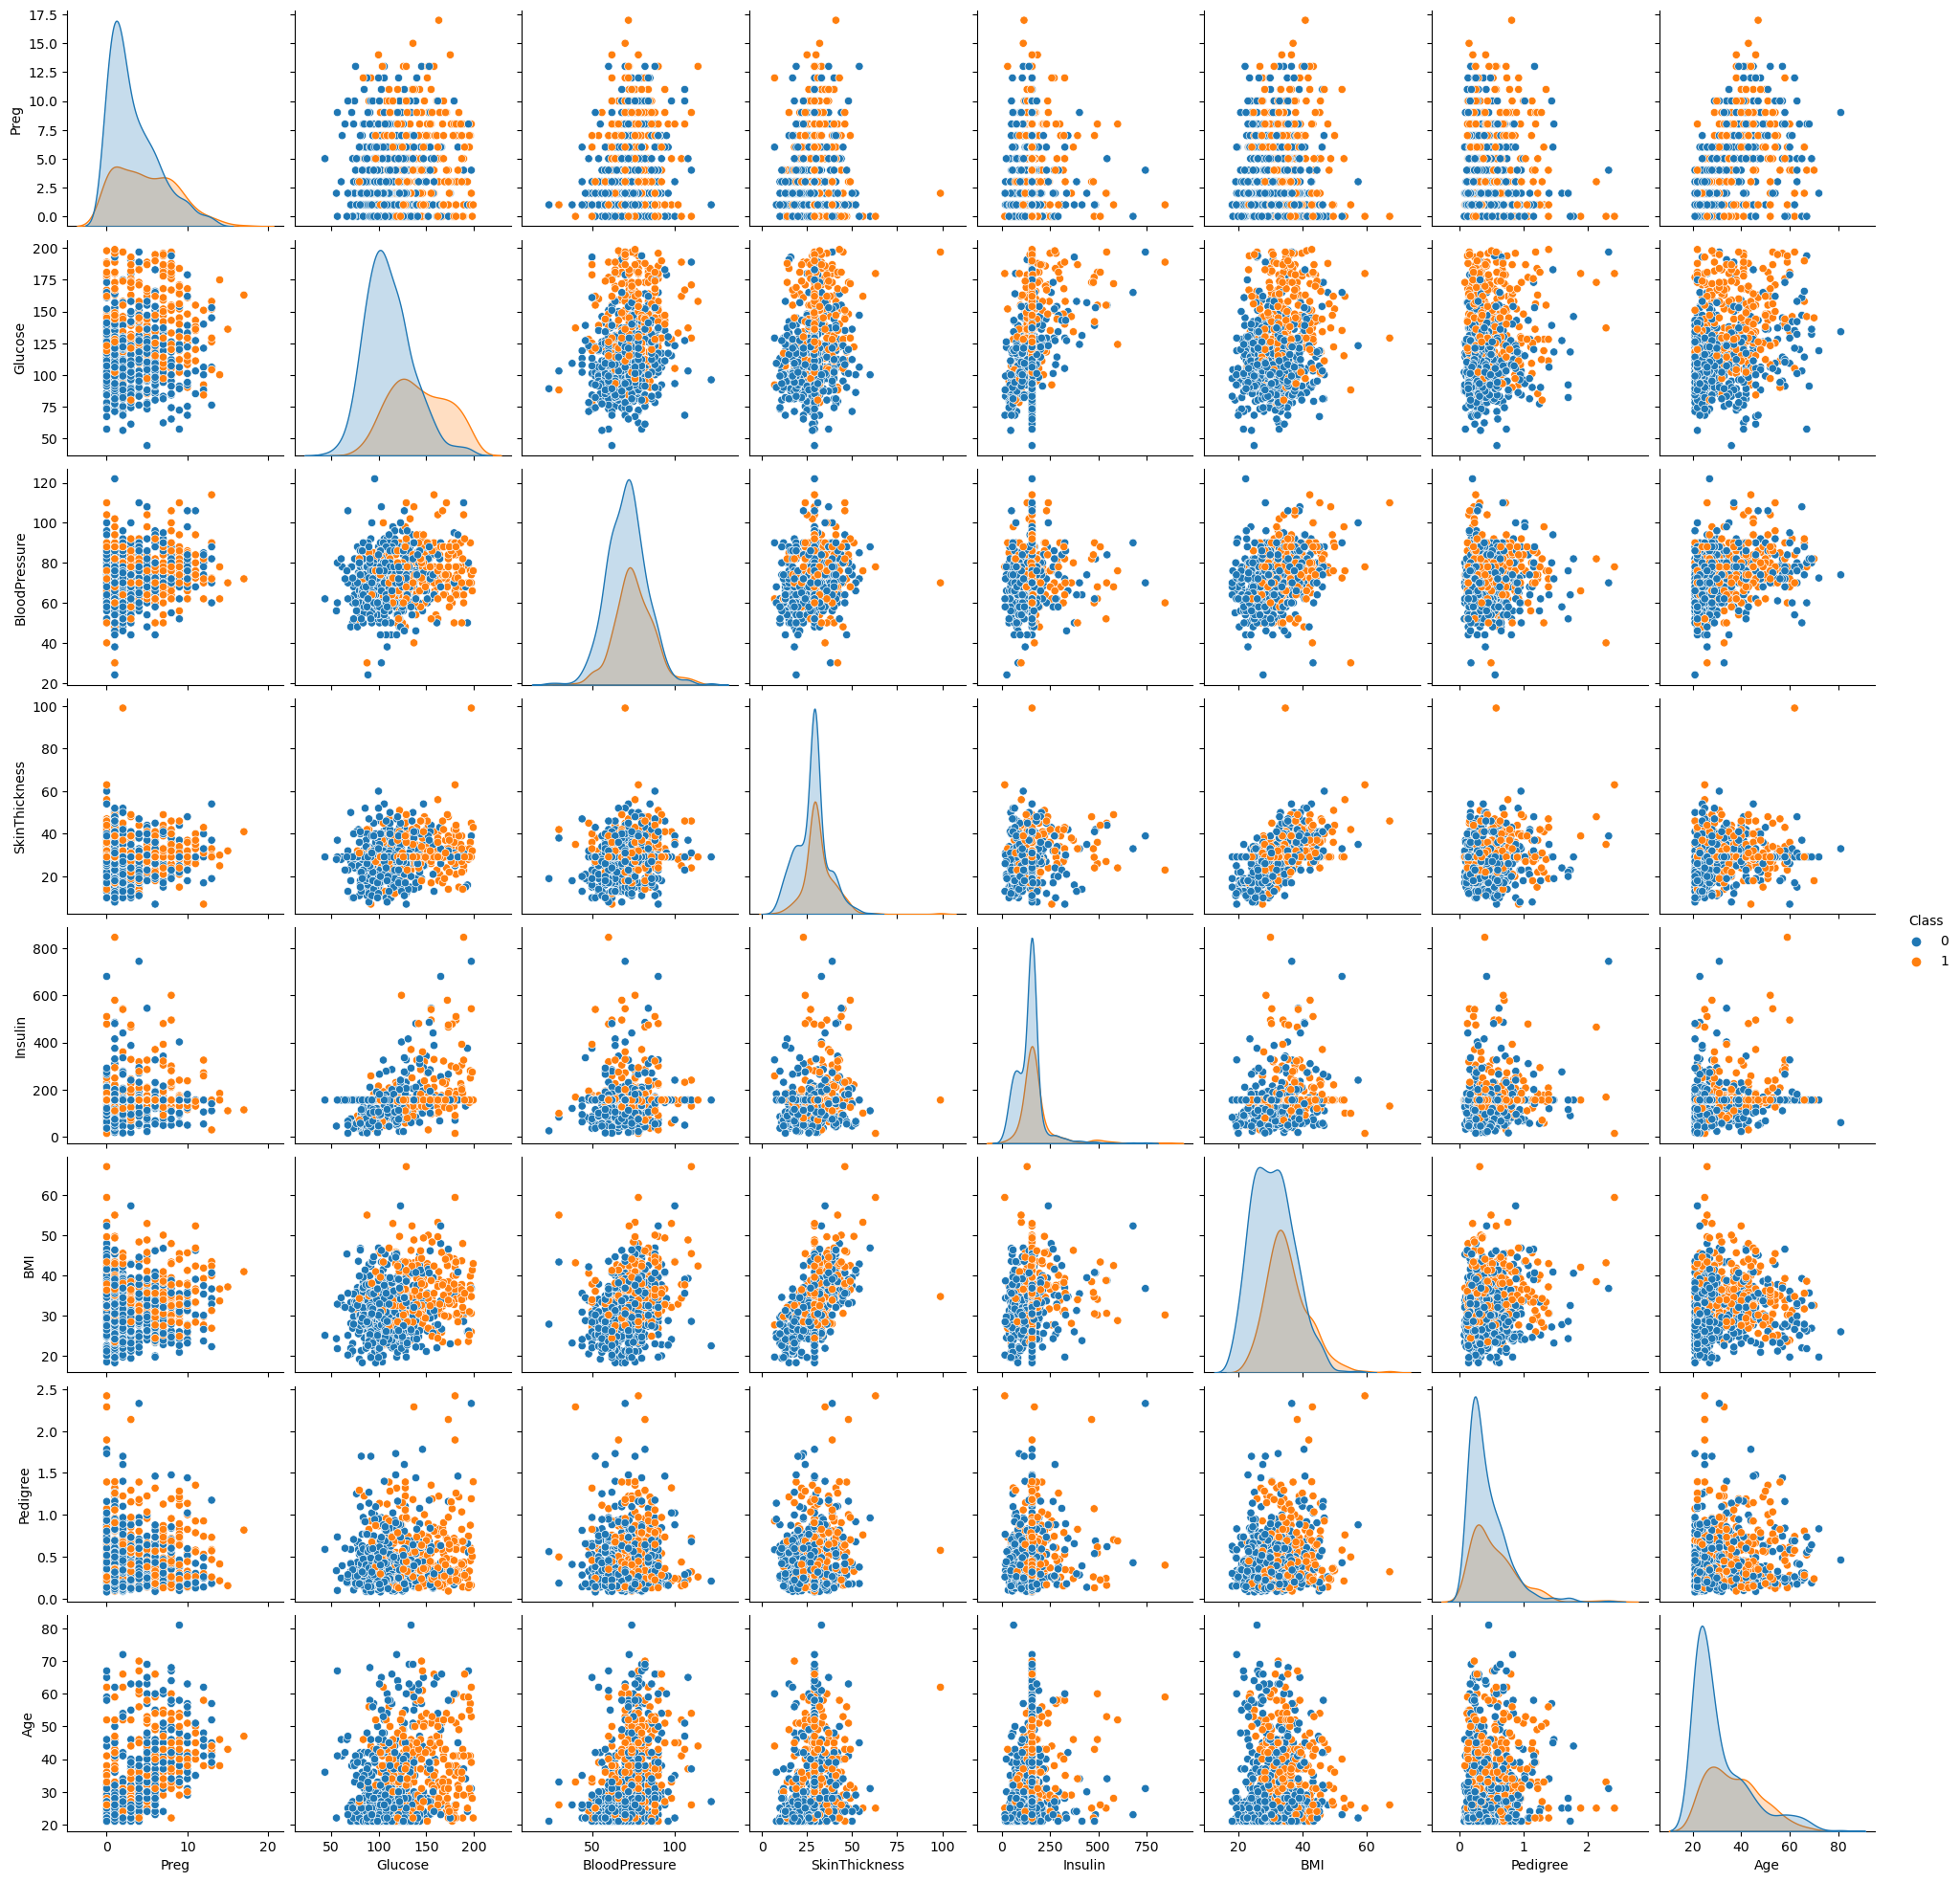

In [29]:
sns.pairplot(data, hue='Class')
plt.show();

In [31]:
round(data['Class'].value_counts(1),2)*100

Class
0    65.0
1    35.0
Name: proportion, dtype: float64

In [32]:
x = data.drop(['Class'], axis=1)
y = data['Class']
x = add_constant(x)
x = pd.get_dummies(x, drop_first=True)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, stratify = y, random_state = 1)

In [33]:
lg = sm.Logit(y_train, x_train.astype(float)).fit()

Optimization terminated successfully.
         Current function value: 0.449508
         Iterations 6


In [34]:
print(lg.summary())

                           Logit Regression Results                           
Dep. Variable:                  Class   No. Observations:                  537
Model:                          Logit   Df Residuals:                      528
Method:                           MLE   Df Model:                            8
Date:                Sat, 12 Apr 2025   Pseudo R-squ.:                  0.3045
Time:                        20:22:09   Log-Likelihood:                -241.39
converged:                       True   LL-Null:                       -347.09
Covariance Type:            nonrobust   LLR p-value:                 2.518e-41
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -9.7226      1.021     -9.522      0.000     -11.724      -7.721
Preg              0.1445      0.039      3.706      0.000       0.068       0.221
Glucose           0.0363      0.005     

In [35]:
pred_train = np.round(lg.predict(x_train)>0.5)

In [36]:
confusion_matrix(y_train, pred_train)

array([[308,  42],
       [ 73, 114]], dtype=int64)

In [37]:
accuracy_score(y_train, pred_train)

0.7858472998137802

In [38]:
vif_series = pd.Series([variance_inflation_factor(x_train.values, i) for i in range(x_train.shape[1])],
                       index = x_train.columns,
                       dtype = float)
vif_series

const            55.156267
Preg              1.418041
Glucose           1.358583
BloodPressure     1.226593
SkinThickness     1.446856
Insulin           1.227806
BMI               1.546783
Pedigree          1.054447
Age               1.637294
dtype: float64